# Выбор лучшего генотипа пшеницы HU по совокупности признаков

Датасет: GPC_Burim_Acko.xlsx


В датасете представлены результаты полевого опыта по 6 генотипам пшеницы (5 линий селекции HU и один контрольный сорт Ayalon). На один генотип есть несколько повторений, для каждого измерены: длина, ширина, соотношение сторон зерна, масса 1000 зерен (TKW) и содержание белка в зерне (GPC).

**Цель проекта:** выявить лучший генотип среди линий HU с точки зрения продуктивности и качества зерна, анализируя все доступные параметры.

**Используемые методы:** описательная статистика (EDA), визуализация распределений, корреляционный анализ, дисперсионный анализ (ANOVA), post-hoc тест Тьюки (Tukey РЫВ), многокритериальное ранжирование (TOPSIS).

## 1. Импорт библиотек

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## 2. Загрузка и первичный осмотр данных

In [8]:
data = pd.read_excel('GPC_Burim_Acko.xlsx')
data.head() 

,Origin,Rep,Gen,Name,Number of grain,Weight of grain,Length,Width,Area,L/W_ratio,TKW,GPC
0,1.0,5,HU-5,BruEin26-F9-1-PS1,174,5,7.365,3.083,16.005,2.414,26.316,24.4
1,2.0,7,HU-7,BruEin26-F9-2-PS1,145,5,7.060,3.138,15.793,2.265,29.240,24.0
2,3.0,8,HU-8,BruEin26-F9-3-PS1,138,5,7.953,3.246,17.891,2.454,30.675,18.3
3,4.0,6,HU-6,BruEin26-F9-4-PS1,102,5,7.724,3.247,17.389,2.407,31.847,15.4
4,5.0,12,HU-12,BruEin26-F9-5-PS1,108,5,7.481,2.945,15.727,2.576,30.120,15.4


In [9]:
data.shape #смотрим на размер

(43, 12)

In [10]:
data.dtypes # тип данных

Origin             float64
Rep                  int64
Gen                    str
Name                   str
Number of grain      int64
Weight of grain      int64
Length             float64
Width              float64
Area               float64
L/W_ratio          float64
TKW                float64
GPC                float64
dtype: object

In [11]:
data.columns = data.columns.str.strip()

## 3. Проверка пропущенных значений

In [12]:
data.isna().sum()

Origin             5
Rep                0
Gen                0
Name               0
Number of grain    0
Weight of grain    0
Length             0
Width              0
Area               0
L/W_ratio          0
TKW                0
GPC                0
dtype: int64

Пропуски обнаружены только в колонке Origin. Мы не включаем ее в список анализируемых признаков, так как она не используется для сравнения.

## 4. Описательная статистика

Определяем список числовых признаков, которые пойдут в анализ. Колонка 'Weight of grain' исключена, так как ее значение одинаковое во всех строках и она не является признаком генотипа.

In [13]:
traits = ['Number of grain', 'Length', 'Width', 'Area', 'L/W_ratio', 'TKW', 'GPC']

In [14]:
data[traits].describe()

,Number of grain,Length,Width,Area,L/W_ratio,TKW,GPC
count,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,127.558140,7.357953,3.097047,16.251535,2.418488,31.566884,19.944186
std,46.092197,0.394040,0.117070,1.043380,0.132298,8.585243,3.341393
min,35.000000,6.701000,2.836000,14.537000,2.163000,22.727000,13.000000
25%,105.000000,7.073500,3.014500,15.607500,2.332000,26.179000,17.600000
50%,137.000000,7.365000,3.117000,16.052000,2.434000,28.902000,21.100000
75%,160.000000,7.682000,3.186500,17.179500,2.518000,32.051000,22.350000
max,209.000000,8.101000,3.316000,18.196000,2.626000,54.945000,24.400000


## 5. Статистика по каждому генотипу

In [15]:
data.groupby('Gen')[traits].agg(['mean', 'std', 'count'])

Number of grain                     Length                     Width  \
                  mean        std count      mean       std count      mean   
Gen                                                                           
Ayalon       51.375000  18.723076     8  6.841625  0.148134     8  3.097375   
HU-12       152.571429  27.488526     7  7.409429  0.177963     7  2.990286   
HU-5        161.142857  15.879007     7  7.345571  0.082429     7  3.009143   
HU-6        131.428571  41.648758     7  7.752571  0.341336     7  3.197286   
HU-7        130.571429  30.880723     7  7.073143  0.100254     7  3.132143   
HU-8        149.142857  20.260212     7  7.799143  0.184688     7  3.156000   

                             Area  ...       L/W_ratio                  \
             std count       mean  ... count      mean       std count   
Gen                                ...                                   
Ayalon  0.092948     8  15.910000  ...     8  2.263000  0.090738     8   
HU-12   0.091653     7  15.773857  ...     7  2.543714  0.060274     7   
HU-5    0.102732     7  15.712000  ...     7  2.499000  0.076330     7   
HU-6    0.108209     7  17.245429  ...     7  2.449286  0.071339     7   
HU-7    0.074450     7  15.777000  ...     7  2.276714  0.063116     7   
HU-8    0.100625     7  17.139714  ...     7  2.501429  0.060887     7   

              TKW                        GPC                  
             mean       std count       mean       std count  
Gen                                                           
Ayalon  47.912625  4.915251     8  14.400000  0.755929     8  
HU-12   26.339286  2.523800     7  20.485714  2.472130     7  
HU-5    26.046571  2.048731     7  22.457143  1.631826     7  
HU-6    29.835857  3.542564     7  19.985714  2.900821     7  
HU-7    28.502429  2.522501     7  22.371429  0.932227     7  
HU-8    28.429429  2.943322     7  20.757143  1.757704     7  

[6 rows x 21 columns]

## 6. Визуализация распределений по генотипам



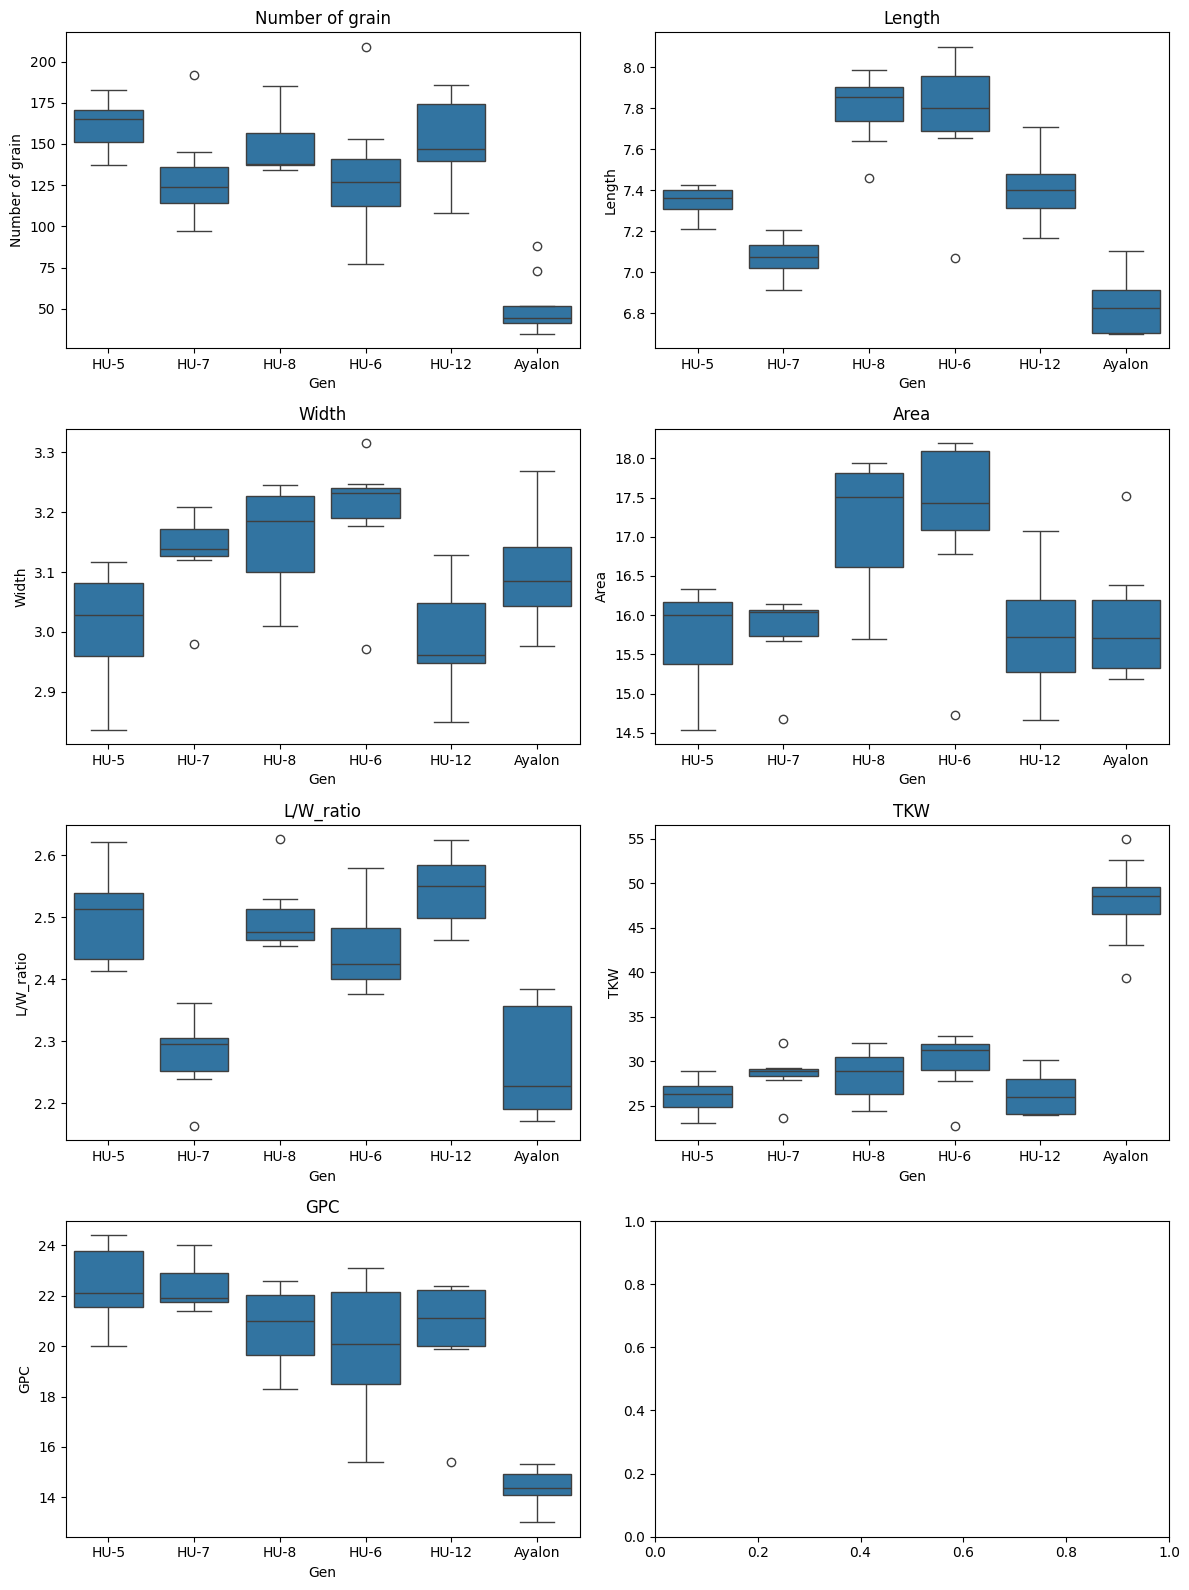

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16)) 
axes = axes.flatten()

for i, trait in enumerate(traits):
    sns.boxplot(data=data, x='Gen', y=trait, ax=axes[i])
    axes[i].set_title(trait)

plt.tight_layout()
plt.show()

## 7. Корреляционный анализ

Проверяем, какие признаки дублируют друг друга, чтобы не учитывать их как независимые критерии в дальнейшем анализе.

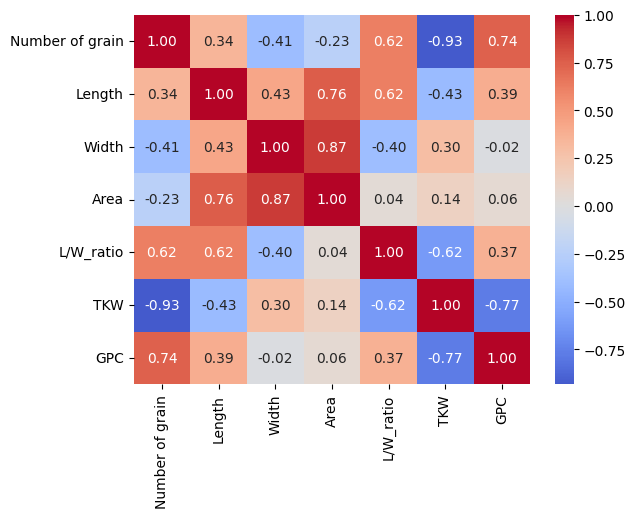

In [18]:
correlation = data[traits].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

### Итог по EDA:
HU-5 и HU-7 - лучшие генотипы по содержанию белка (GPC).

Чем крупнее зерно, то есть выше TKW, тем ниже GPC.

Length, Width, Area - коллинеарная группа, Number of grain и TKW также сильно коррелируют.

Генотип Ayalon визуально отличается от всех линий HU по большинству признаков - меньше зерен в пробе, высокий TKW, низкий GPC.

## Дисперсионный анализ ANOVA

Проверяем, действительно ли визуально заметные различия между генотипами статистически значимы, или же они возникли случайно при небольшом числе повторений.

Н0: все генотипы имею одинаковое среднее значение признака

Н1: хотя бы один генотип отличается от других

Если p-value < 0.05, H0 - отвергается и различия будут считаться статистически значимыми.

In [19]:
groups = [data[data['Gen'] == g]['GPC'] for g in data['Gen'].unique()]

In [20]:
f_stat, p_value = stats.f_oneway(*groups)
print(f'F = {f_stat:.3f}, p-value = {p_value:.2e}')

F = 19.112, p-value = 2.32e-09


p-value = 2.32e-09, соответственно различия между всеми 6 генотипами по GPC статистически высоко значимы.
Повторям тест для всех признаков


In [21]:
anova_results = []
for trait in traits:
    groups = [data[data['Gen'] == g][trait] for g in data['Gen'].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    anova_results.append({'trait': trait, 'F': f_stat, 'p_value': p_value})

anova_df = pd.DataFrame(anova_results)
anova_df

,trait,F,p_value
0,Number of grain,16.971543,1.051506e-08
1,Length,28.387739,1.033003e-11
2,Width,5.185167,1.052115e-03
3,Area,5.066017,1.232020e-03
4,L/W_ratio,21.070684,6.451316e-10
5,TKW,50.161343,1.791710e-15
6,GPC,19.112082,2.324681e-09


Все 7 признаков показывают статистически значимые различия между генотипами (p < 0.05). Наиболее сильно генотипы разделяются по TKW (F=50) и Length (F=28).

## 9. Post-hoc тест Тьюки(Tukey HSD)

Проверяем попарные различия между всеми 6 генотипами по ключевым признакам GPC и TKW.

In [22]:
tukey_gpc = pairwise_tukeyhsd(endog=data["GPC"], groups=data["Gen"], alpha=0.05)
print(tukey_gpc)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Ayalon  HU-12   6.0857    0.0  3.1614    9.01   True
Ayalon   HU-5   8.0571    0.0  5.1329 10.9814   True
Ayalon   HU-6   5.5857    0.0  2.6614    8.51   True
Ayalon   HU-7   7.9714    0.0  5.0472 10.8957   True
Ayalon   HU-8   6.3571    0.0  3.4329  9.2814   True
 HU-12   HU-5   1.9714 0.3833 -1.0487  4.9916  False
 HU-12   HU-6     -0.5  0.996 -3.5202  2.5202  False
 HU-12   HU-7   1.8857 0.4325 -1.1345  4.9059  False
 HU-12   HU-8   0.2714 0.9998 -2.7487  3.2916  False
  HU-5   HU-6  -2.4714 0.1632 -5.4916  0.5487  False
  HU-5   HU-7  -0.0857    1.0 -3.1059  2.9345  False
  HU-5   HU-8     -1.7 0.5461 -4.7202  1.3202  False
  HU-6   HU-7   2.3857 0.1921 -0.6345  5.4059  False
  HU-6   HU-8   0.7714 0.9713 -2.2487  3.7916  False
  HU-7   HU-8  -1.6143 0.6001 -4.6345  1.4059  False
----------------------------------------------

In [23]:
tukey_tkw = pairwise_tukeyhsd(endog=data["TKW"], groups=data["Gen"], alpha=0.05)
print(tukey_tkw)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
Ayalon  HU-12 -21.5733    0.0 -26.6725 -16.4742   True
Ayalon   HU-5 -21.8661    0.0 -26.9652 -16.7669   True
Ayalon   HU-6 -18.0768    0.0 -23.1759 -12.9776   True
Ayalon   HU-7 -19.4102    0.0 -24.5094  -14.311   True
Ayalon   HU-8 -19.4832    0.0 -24.5824  -14.384   True
 HU-12   HU-5  -0.2927    1.0  -5.5591   4.9737  False
 HU-12   HU-6   3.4966 0.3647  -1.7698    8.763  False
 HU-12   HU-7   2.1631 0.8174  -3.1033   7.4295  False
 HU-12   HU-8   2.0901 0.8377  -3.1763   7.3565  False
  HU-5   HU-6   3.7893 0.2797  -1.4771   9.0557  False
  HU-5   HU-7   2.4559 0.7262  -2.8105   7.7223  False
  HU-5   HU-8   2.3829 0.7503  -2.8835   7.6493  False
  HU-6   HU-7  -1.3334 0.9724  -6.5998    3.933  False
  HU-6   HU-8  -1.4064 0.9653  -6.6728     3.86  False
  HU-7   HU-8   -0.073    1.0  -5.3394   5.1934  False
----------

## Вывод
По обоим признакам (GPC и TKW) значимые различия (reject=True) обнаружены только в парах, где участвует Ayalon. Между собой 5 линий HU статистически неразличимы, это означает, что Ayalon - контрольный сорт другого типа.

## 10. Исключение контрольного генотипа Ayalon

In [24]:
data_hu = data[data['Gen'] != 'Ayalon'].copy()

In [25]:
data_hu.shape
data_hu['Gen'].unique()

<ArrowStringArray>
['HU-5', 'HU-7', 'HU-8', 'HU-6', 'HU-12']
Length: 5, dtype: str

In [26]:
data_hu.head

<bound method NDFrame.head of     Origin  Rep    Gen                Name  Number of grain  Weight of grain  \
0      1.0    5   HU-5   BruEin26-F9-1-PS1              174                5   
1      2.0    7   HU-7   BruEin26-F9-2-PS1              145                5   
2      3.0    8   HU-8   BruEin26-F9-3-PS1              138                5   
3      4.0    6   HU-6   BruEin26-F9-4-PS1              102                5   
4      5.0   12  HU-12   BruEin26-F9-5-PS1              108                5   
5      6.0    6   HU-6   BruEin26-F9-6-PS1               77                5   
6      7.0    7   HU-7   BruEin26-F9-7-PS1              127                5   
7      8.0    8   HU-8   BruEin26-F9-8-PS1              137                5   
8      9.0   12  HU-12   BruEin26-F9-9-PS1              181                5   
9     10.0    5   HU-5  BruEin26-F9-10-PS1              147                5   
10    11.0    6   HU-6  BruEin26-F9-11-PS1              129                5   
11    12.0

In [27]:
data_hu.groupby('Gen')[traits].agg(['mean', 'std', 'count'])

Number of grain                     Length                     Width  \
                 mean        std count      mean       std count      mean   
Gen                                                                          
HU-12      152.571429  27.488526     7  7.409429  0.177963     7  2.990286   
HU-5       161.142857  15.879007     7  7.345571  0.082429     7  3.009143   
HU-6       131.428571  41.648758     7  7.752571  0.341336     7  3.197286   
HU-7       130.571429  30.880723     7  7.073143  0.100254     7  3.132143   
HU-8       149.142857  20.260212     7  7.799143  0.184688     7  3.156000   

                            Area  ...       L/W_ratio                  \
            std count       mean  ... count      mean       std count   
Gen                               ...                                   
HU-12  0.091653     7  15.773857  ...     7  2.543714  0.060274     7   
HU-5   0.102732     7  15.712000  ...     7  2.499000  0.076330     7   
HU-6   0.108209     7  17.245429  ...     7  2.449286  0.071339     7   
HU-7   0.074450     7  15.777000  ...     7  2.276714  0.063116     7   
HU-8   0.100625     7  17.139714  ...     7  2.501429  0.060887     7   

             TKW                        GPC                  
            mean       std count       mean       std count  
Gen                                                          
HU-12  26.339286  2.523800     7  20.485714  2.472130     7  
HU-5   26.046571  2.048731     7  22.457143  1.631826     7  
HU-6   29.835857  3.542564     7  19.985714  2.900821     7  
HU-7   28.502429  2.522501     7  22.371429  0.932227     7  
HU-8   28.429429  2.943322     7  20.757143  1.757704     7  

[5 rows x 21 columns]

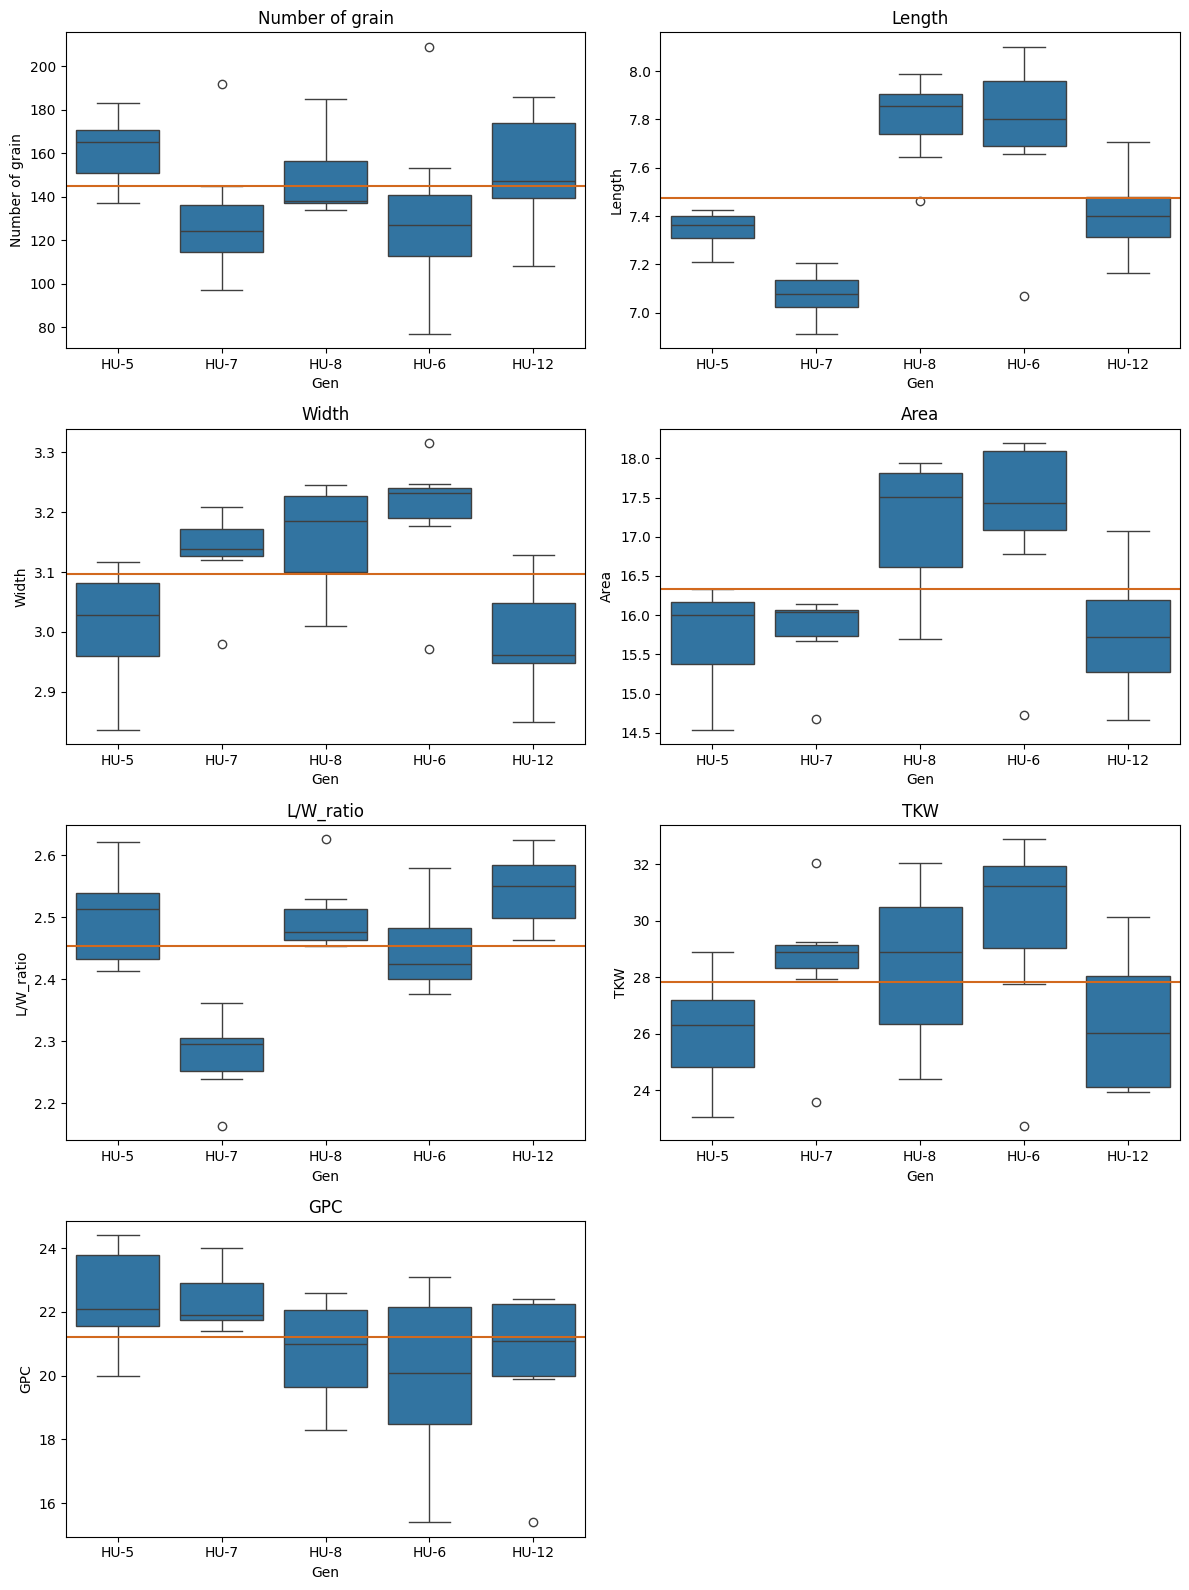

In [28]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16)) 
axes = axes.flatten()

for i, trait in enumerate(traits):
    sns.boxplot(data=data_hu, x='Gen', y=trait, ax=axes[i])
    axes[i].set_title(trait)
    overall_mean = data_hu[trait].mean()
    axes[i].axhline(overall_mean, color='#D2691E', linewidth=1.5, label='Среднее значение по всем генотипам HU')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

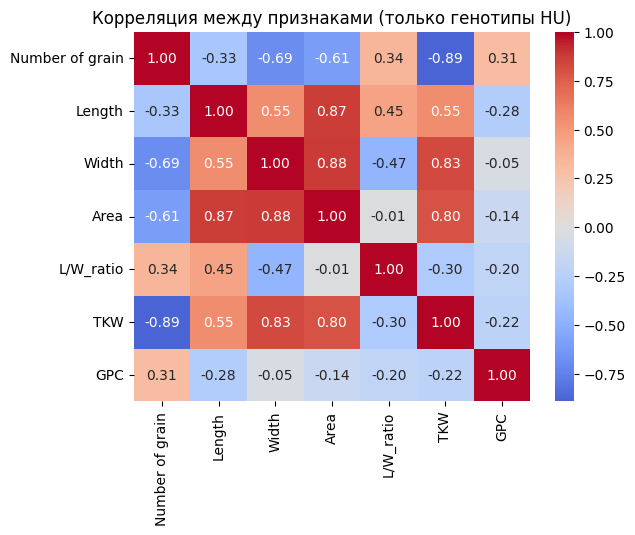

In [29]:
correlation = data_hu[traits].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция между признаками (только генотипы HU)')
plt.show()

## 11. ANOVA среди линий HU
Проверяем, остаются ли различия между линиями HU статистически значимыми после удаления контроля Ayalon. 

In [30]:
anova_results_hu = []

for trait in traits:
    formula = f'Q("{trait}") ~ Gen' #используем Q(''), так как некоторые названия содержат пробелы
    model = ols(formula, data=data_hu).fit()
    table = anova_lm(model)
    
    f_stat = table.loc['Gen', 'F']
    p_value = table.loc['Gen', 'PR(>F)']

    anova_results_hu.append({'trait': trait, 'F': f_stat, 'p_value': p_value})
    
anova_df_hu = pd.DataFrame(anova_results_hu)
anova_df_hu

,trait,F,p_value
0,Number of grain,1.550026,2.131720e-01
1,Length,16.022630,4.013486e-07
2,Width,6.398475,7.574356e-04
3,Area,5.739733,1.489214e-03
4,L/W_ratio,17.223368,1.941318e-07
5,TKW,2.348559,7.689712e-02
6,GPC,2.123745,1.023885e-01


## Вывод
Без Ayalon линии HU статистически значимо различаются по Length, Width, Area, L/W_ratio (все p-value < 0.01), но не различаются значимо по ключевым признакам - GPC(p=0.10), TKW(p=0.08) и Number of grain(p=0.21). 
Это означает, что выбрать лучший генотип по одному показателю нельзя и мы будем использовать многокритериальный подход, который будет учитывать совокупноть признаков.

## 12. Многокритериальное ранжирование (TOPSIS)

Для итогового выбора лучшего генотипа применяем метод TOPSIS. Метод строит гипотетическую идеальную точку(максимум по всем критериям) и анти-идеальную(минимум), а затем ранжирует объекты по близости к идеалу и удаленности от анти-идеала.

**Выбранные критерии:** GPC и TKW.

In [31]:
#средние значения по генотипу
topsis_data = data_hu.groupby('Gen')[['GPC', 'TKW']].mean()
topsis_data

,GPC,TKW
Gen,,
HU-12,20.485714,26.339286
HU-5,22.457143,26.046571
HU-6,19.985714,29.835857
HU-7,22.371429,28.502429
HU-8,20.757143,28.429429


In [32]:
#векторная нормализация- приводим оба признака к сопоставимой шкале
norm_data = topsis_data / np.sqrt((topsis_data**2).sum())
norm_data

,GPC,TKW
Gen,,
HU-12,0.431421,0.422689
HU-5,0.472939,0.417992
HU-6,0.420891,0.478802
HU-7,0.471133,0.457403
HU-8,0.437137,0.456232


In [33]:
# взвешивание - равные веса
weights = {'GPC': 0.5, 'TKW': 0.5}
weighted_data = norm_data * pd.Series(weights)
weighted_data

,GPC,TKW
Gen,,
HU-12,0.215711,0.211345
HU-5,0.236469,0.208996
HU-6,0.210446,0.239401
HU-7,0.235567,0.228702
HU-8,0.218569,0.228116


In [34]:
ideal_best = weighted_data.max() #идеальная точка
ideal_worst = weighted_data.min() #анти-идеальная точка
print('Идеальная точка:\n', ideal_best)
print('\nАнти-идеальная точка:\n',ideal_worst)

Идеальная точка:
 GPC    0.236469
TKW    0.239401
dtype: float64

Анти-идеальная точка:
 GPC    0.210446
TKW    0.208996
dtype: float64


In [35]:
#евклидово расстояние до идеала и анти-идеала
dist_best = np.sqrt(((weighted_data - ideal_best)**2).sum(axis=1))
dist_worst = np.sqrt(((weighted_data - ideal_worst)**2).sum(axis=1))

print(dist_best)
print(dist_worst)

Gen
HU-12    0.034901
HU-5     0.030405
HU-6     0.026024
HU-7     0.010737
HU-8     0.021161
dtype: float64
Gen
HU-12    0.005765
HU-5     0.026024
HU-6     0.030405
HU-7     0.031928
HU-8     0.020774
dtype: float64


In [36]:
#итог
topsis_score = dist_worst / (dist_best + dist_worst)
topsis_data['TOPSIS_score'] = topsis_score
topsis_data.sort_values('TOPSIS_score', ascending=False)

,GPC,TKW,TOPSIS_score
Gen,,,
HU-7,22.371429,28.502429,0.748334
HU-6,19.985714,29.835857,0.538822
HU-8,20.757143,28.429429,0.495384
HU-5,22.457143,26.046571,0.461178
HU-12,20.485714,26.339286,0.141765


## Итоговый рейтинг генотипов HU 

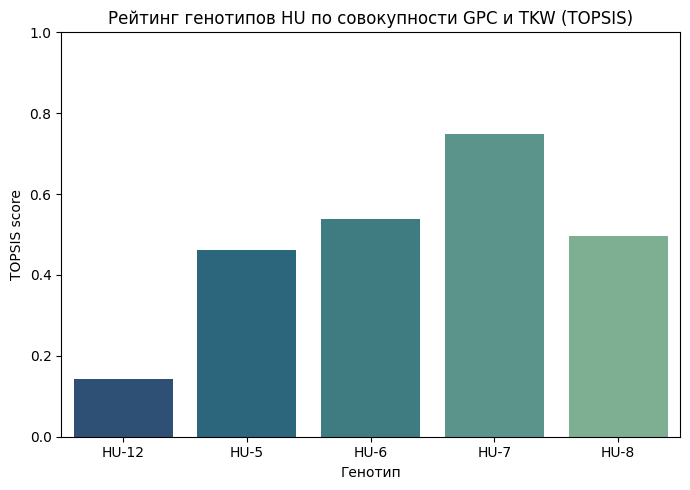

In [37]:
plt.figure(figsize=(7,5))
colors = sns.color_palette('crest', len(topsis_data))[::-1]
sns.barplot(x=topsis_data.index, y=topsis_data['TOPSIS_score'], palette=colors, hue=topsis_data.index, legend=False)
plt.ylabel('TOPSIS score')
plt.xlabel('Генотип')
plt.title('Рейтинг генотипов HU по совокупности GPC и TKW (TOPSIS)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Выводы

1. Ayalon (контрольный сорт) - статистически значимо отличается от всех линий HU по всем измеренным признакам - меньше зерен в пробе, крупнее отдельное зерно, низкое содержание белка.
2. Между линиями HU значимые различия обнаружены в длине, ширине, площади, соотрошении сторон зерна, но не по ключевым признакам - GPC и TKW (p>0.05 по ANOVA).
3. Было применено многокритериальное ранжирование (TOPSIS) по GPC и TKW, так как выделить лидера по одному признаку нельзя.
4. По результатам TOPSIS лучший результат показывает генотип HU-7 (TOPSIS score=0.75), за ним следует HU-6 и HU-8.